# Evaluation Task V: Quantum Graph Neural Network (QGNN)
**Author:** Aditya Shintre

### 1. Conceptual Framework: The Quantum Graph Neural Network
In Task II, we utilized Classical Graph Neural Networks (GNNs) to classify particle jets. The core mechanism was passing physical features (momentum, rapidity) along the edges of a K-Nearest Neighbors (KNN) graph constructed in $\Delta R$ detector space.

To map this into a Quantum Graph Neural Network (QGNN), we must translate classical structures into quantum topologies:
1.  **Nodes as Qubits:** Each particle in a sub-shower is represented by a single qubit.
2.  **Features as Rotations:** Classical features (e.g., transverse momentum $p_T$) dictate the initial angle of parameterized rotation gates ($R_y$, $R_z$) to encode the data into the quantum state.
3.  **Edges as Entanglement:** *This is the crucial step.* We only apply two-qubit entangling gates (e.g., $ZZ$ interaction) between qubits that share a physical edge in our classical KNN graph. If two particles are not neighbors, their qubits do not directly interact.
4.  **Weights as Parameterized Gates:** The trainable weights of the neural network become parameterized local rotations applied after the entangling step.
5.  **Global Pooling as Readout:** The classification is achieved by measuring the expectation value $\langle Z \rangle$ of each qubit and summing them.

In [1]:
# 1. Environment Initialization
!pip install pennylane -q
!pip install matplotlib -q

import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

print(f"PennyLane version: {qml.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 90.1 MB/s eta 0:00:00
PennyLane version: 0.44.0


### 2. Simulating a Jet Sub-Shower Graph
To implement the QGNN, we first define the classical geometry. We will simulate a simplified 3-particle jet sub-shower.

* **Nodes:** 3 particles (Qubit 0, Qubit 1, Qubit 2).
* **Edges:** Based on a hypothetical $\Delta R$ KNN graph, Particle 0 is connected to Particle 1, and Particle 1 is connected to Particle 2. Particle 0 and 2 are *not* connected.
* **Features:** We assign a simplified scalar feature (like normalized $p_T$) to each particle.

In [2]:
# 2. Defining the Classical Graph
# Number of particles
n_particles = 3

# Define the edges based on our classical KNN logic
graph_edges = [(0, 1), (1, 2)]

# Simulated classical features for each particle
particle_features = np.array([0.5, 1.2, -0.3], requires_grad=False)

print(f"Graph Edges: {graph_edges}")
print(f"Particle Features: {particle_features}")

Graph Edges: [(0, 1), (1, 2)]
Particle Features: [ 0.5  1.2 -0.3]


### 3. The QGNN Circuit Implementation
We build a parameterized quantum circuit using PennyLane.

**The Architecture:**
1.  **Data Encoding:** We use `qml.RY` gates to embed the `particle_features` into the $|0\rangle$ state of each corresponding qubit.
2.  **The QGNN Layer:**
    * **Graph Entanglement:** We iterate through our `graph_edges`. For every edge, we apply a parameterized `IsingZZ` gate. This allows neighboring particles to share information.
    * **Local Update:** We apply a parameterized `RY` gate to every single qubit, acting as the trainable "weights" of the network layer.
3.  **Measurement:** We measure the Pauli-Z expectation value for each qubit.

In [3]:
# 3. Circuit Implementation
# Initialize the quantum device
dev = qml.device("default.qubit", wires=n_particles)

@qml.qnode(dev)
def qgnn_circuit(features, edge_weights, node_weights, edges):
    """
    A single-layer Quantum Graph Neural Network.

    Args:
        features: Classical data to encode (length: n_particles)
        edge_weights: Trainable parameters for the entanglement gates (length: len(edges))
        node_weights: Trainable parameters for local rotations (length: n_particles)
        edges: List of tuples defining the graph connections
    """

    # 1. Data Encoding (Angle Embedding)
    for i in range(n_particles):
        qml.RY(features[i], wires=i)

    # 2. QGNN Layer: Graph-Based Entanglement (The "Message Passing")
    for idx, edge in enumerate(edges):
        # We only entangle qubits that share a classical edge
        qml.IsingZZ(edge_weights[idx], wires=[edge[0], edge[1]])

    # 3. QGNN Layer: Local Updates (The "Weights")
    for i in range(n_particles):
        qml.RY(node_weights[i], wires=i)

    # 4. Measurement (Readout)
    return [qml.expval(qml.PauliZ(i)) for i in range(n_particles)]

# Initialize random trainable weights
np.random.seed(42)
initial_edge_weights = np.random.uniform(0, 2 * np.pi, size=len(graph_edges), requires_grad=True)
initial_node_weights = np.random.uniform(0, 2 * np.pi, size=n_particles, requires_grad=True)

print("Circuit built successfully.")

Circuit built successfully.


### 4. Circuit Execution and Visualization
We will perform a forward pass of our QGNN with the simulated features and randomly initialized weights.

Crucially, we will draw the circuit to visually verify that the quantum topology matches our classical graph structure.

Forward Pass Results
Individual Qubit Expectations (<Z>): [tensor(-0.43493708, requires_grad=True), tensor(-0.56043996, requires_grad=True), tensor(0.7657114, requires_grad=True)]
Aggregated Jet Score: -0.2297

Quantum Circuit Architecture


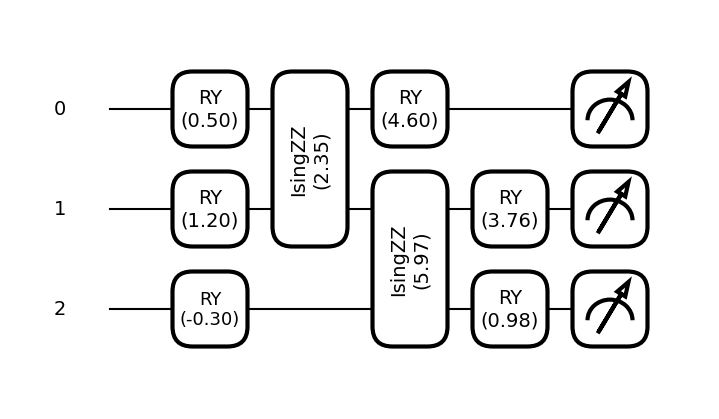

In [7]:
# 4. Execution and Drawing
# Perform a forward pass
result = qgnn_circuit(particle_features, initial_edge_weights, initial_node_weights, graph_edges)

# Calculate a "Global Readout"
jet_score = np.sum(result)

print("Forward Pass Results")
print(f"Individual Qubit Expectations (<Z>): {result}")
print(f"Aggregated Jet Score: {jet_score:.4f}")
print("\nQuantum Circuit Architecture")

# Draw the circuit
fig, ax = qml.draw_mpl(qgnn_circuit, decimals=2)(particle_features, initial_edge_weights, initial_node_weights, graph_edges)
plt.show()

### 5. Discussion: Taking Advantage of the Graph
The visual output of the circuit perfectly demonstrates how this architecture fulfills the prompt's requirement to "take advantage of the graph representation."

In a dense, fully-connected Quantum Neural Network, every qubit would be entangled with every other qubit, requiring $\frac{N(N-1)}{2}$ operations and completely ignoring spatial geometry.

In our QGNN:
1.  **Sparsity and Physical Accuracy:** The `IsingZZ` gates are applied *only* between Wire 0 & Wire 1, and Wire 1 & Wire 2. Wire 0 and Wire 2 never interact directly. The quantum circuit maps perfectly to the specific localized physical interactions dictated by the $\Delta R$ KNN geometry.
2.  **Scalability:** By restricting entanglement to local edges, the circuit depth remains shallow even as the number of particles increases, mitigating noise and making the model more viable for Near-Term Intermediate-Scale Quantum (NISQ) devices.